Paper detected and cropped.
Stats → Saturation: 27.60, Brightness: 194.49
Detected: Shadowy Crayon → Whitening


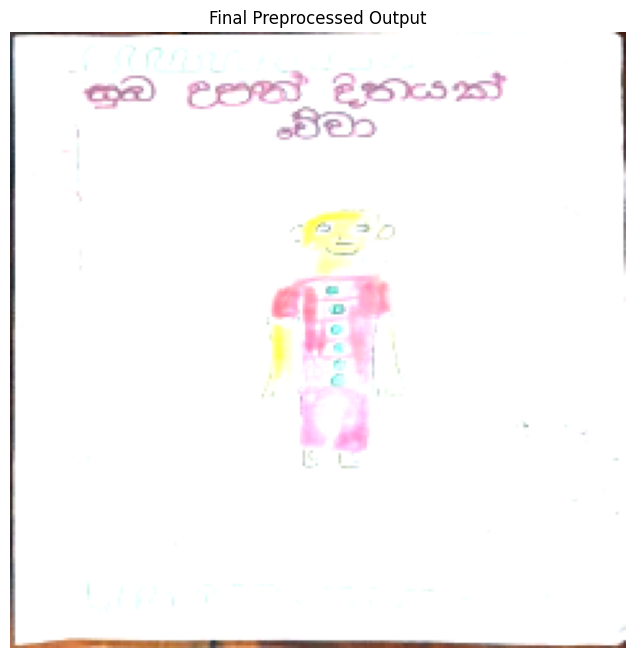

Saved as: processed_wood bg1.jpeg


In [2]:
# ============================================================
# SMART PREPROCESSING PIPELINE FOR CHILDREN'S DRAWINGS
# Pencil + Crayon Adaptive Enhancement (PyCharm Compatible)
# ============================================================

# -----------------------------
# 1. IMPORT REQUIRED LIBRARIES
# -----------------------------
# cv2  : Core computer vision operations
# numpy: Mathematical operations
# matplotlib: Visualization
# os   : File handling

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# 2. DEFINE DATASET IMAGE SIZE
# -----------------------------
# All images are standardized to ensure model compatibility
TARGET_SIZE = (240, 240)

# -------------------------------------------------------
# 3. HELPER FUNCTION: POINT ORDERING
# -------------------------------------------------------
# Ensures consistent corner ordering for perspective transform
# Order: Top-left, Top-right, Bottom-right, Bottom-left

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

# -------------------------------------------------------
# 4. PENCIL DRAWING ENHANCEMENT PIPELINE
# -------------------------------------------------------
# Designed for faint graphite drawings with low saturation
# Enhances strokes without destroying line structure

def enhance_pencil_drawing(img):

    # Convert to grayscale (pencil drawings rely on intensity, not color)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # CLAHE boosts local contrast, making faint strokes visible
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Remove paper grain while preserving edges
    denoised = cv2.fastNlMeansDenoising(enhanced, None, 10, 7, 21)

    # Adaptive threshold creates clean pencil-like strokes
    final_scan = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

    # Convert back to 3 channels to maintain dataset consistency
    return cv2.cvtColor(final_scan, cv2.COLOR_GRAY2BGR)

# -------------------------------------------------------
# 5. CRAYON / MARKER WHITENING PIPELINE
# -------------------------------------------------------
# Removes shadows and uneven lighting while preserving color

def apply_camscanner_effect(img):

    result_planes = []
    rgb_planes = cv2.split(img)

    for plane in rgb_planes:
        # Estimate background via dilation
        dilated = cv2.dilate(plane, np.ones((7, 7), np.uint8))

        # Smooth background illumination
        bg = cv2.medianBlur(dilated, 21)

        # Shadow removal via difference normalization
        diff = 255 - cv2.absdiff(plane, bg)
        norm = cv2.normalize(diff, None, 0, 255,
                              cv2.NORM_MINMAX, cv2.CV_8UC1)
        result_planes.append(norm)

    # Merge enhanced channels
    result = cv2.merge(result_planes)

    # Slight contrast and brightness boost
    return cv2.convertScaleAbs(result, alpha=1.2, beta=10)

# -------------------------------------------------------
# 6. MAIN DRAWING PROCESSING PIPELINE
# -------------------------------------------------------
# Automatically:
# - Detects paper
# - Corrects perspective
# - Determines pencil vs crayon
# - Applies the correct enhancement

def process_drawing_pipeline(image_path, output_size=TARGET_SIZE):

    # --- STEP 1: LOAD IMAGE ---
    if not os.path.exists(image_path):
        print(f"Error: File not found -> {image_path}")
        return None

    img = cv2.imread(image_path)
    original = img.copy()

    # --- STEP 2: PAPER EDGE DETECTION ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blurred, 30, 200)
    edges = cv2.dilate(edges, np.ones((5, 5), np.uint8), iterations=2)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    screenCnt = None
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            screenCnt = approx
            break

    # --- STEP 3: PERSPECTIVE CORRECTION ---
    if screenCnt is not None:
        rect = order_points(screenCnt.reshape(4, 2))
        (tl, tr, br, bl) = rect

        width = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))
        height = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))

        dst = np.array([
            [0, 0],
            [width - 1, 0],
            [width - 1, height - 1],
            [0, height - 1]
        ], dtype="float32")

        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(original, M, (width, height))
        print("Paper detected and cropped.")
    else:
        print("Paper not detected — using full image.")
        warped = original

    # --- STEP 4: RESIZE ---
    resized = cv2.resize(warped, output_size, interpolation=cv2.INTER_AREA)

    # --- STEP 5: MATERIAL CLASSIFICATION ---
    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)
    mean_sat = np.mean(hsv[:, :, 1])
    mean_val = np.mean(hsv[:, :, 2])

    print(f"Stats → Saturation: {mean_sat:.2f}, Brightness: {mean_val:.2f}")

    # Decision Logic
    if mean_sat < 25:
        print("Detected: Pencil Drawing → Contrast Enhancement")
        final = enhance_pencil_drawing(resized)
    elif mean_val < 210:
        print("Detected: Shadowy Crayon → Whitening")
        final = apply_camscanner_effect(resized)
    else:
        print("Detected: Bright Crayon → Keeping Natural")
        final = resized

    return final

# -------------------------------------------------------
# 7. EXECUTION & VISUALIZATION
# -------------------------------------------------------

# CHANGE THIS to your local image path
input_image = "wood bg1.jpeg"

processed = process_drawing_pipeline(input_image)

if processed is not None:
    display_img = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(display_img)
    plt.title("Final Preprocessed Output")
    plt.axis("off")
    plt.show()

    # Save result safely
    save_name = "processed_" + os.path.basename(input_image)
    cv2.imwrite(save_name, processed)
    print(f"Saved as: {save_name}")
